# Predicting Depression Among Students Using Machine Learning

## Introduction



Mental health among university students has become an increasing global concern. Academic pressure, financial stress, lifestyle factors, and family circumstances can all contribute to depression and reduced well-being. Early identification of students at risk may enable institutions to provide timely support and intervention.



In this project, machine learning techniques are used to analyse a student mental health dataset to predict whether a student is experiencing depression based on demographic, academic, and lifestyle characteristics.



## Objective



The objective of this project is to explore factors associated with student depression and compare the performance of machine learning models in predicting depression status.

## Dataset Description

The dataset used in this project was obtained from Kaggle (https://www.kaggle.com/datasets/ikynahidwin/depression-student-dataset/data) on **23 July 2026**. It contains demographic, academic, and lifestyle information collected from students, together with a binary target variable indicating whether a student is experiencing depression.

| Property | Description |
|----------|-------------|
| **Source** | Kaggle – Student Depression Dataset |
| **Observations** | 502 |
| **Features** | 11 |
| **Numerical Variables** | 5 |
| **Categorical Variables** | 6 |
| **Target Variable** | Depression (Yes/No) |

## Data inspection & preprocessing

In [ ]:
!pwd

/content


In [ ]:
!ls

sample_data


In [7]:
#load the relavant packages
import gdown
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#prepare to load the data
file_id = "1dj5aP1Rpe51gWknc9xxieGxr9F5GoMs9"

url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "Depression Student Dataset.csv", quiet=False)

#load necessary dataset


hdu=pd.read_csv("Depression Student Dataset.csv")


Downloading...
From: https://drive.google.com/uc?id=1dj5aP1Rpe51gWknc9xxieGxr9F5GoMs9
To: /content/Depression Student Dataset.csv
100%|██████████| 28.2k/28.2k [00:00<00:00, 41.7MB/s]


This section explores the structure and quality of the dataset before any analysis is performed. The objective is to understand the available variables, identify potential data quality issues, and prepare the data for exploratory analysis and machine learning.

In [8]:
hdu.head() #print first few lines to inspect

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [25]:
# Rename long columns for readability
hdu = hdu.rename(columns={
    'Have you ever had suicidal thoughts ?': 'Suicidal Thoughts',
    'Family History of Mental Illness': 'Family History'
})

In [26]:
# Shorten sleep duration categories
hdu['Sleep Duration'] = hdu['Sleep Duration'].replace({
    'Less than 5 hours': '<5 hours',
    'More than 8 hours': '>8 hours'
})

#preview the updated table
hdu.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Suicidal Thoughts,Study Hours,Financial Stress,Family History,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,>8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,>8 hours,Healthy,Yes,4,2,Yes,No


In [27]:
hdu.shape #check how many rows and columns the dataset has

(502, 11)

In [28]:
hdu.info() # Inspect the dataset structure and verify data types and missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              502 non-null    object 
 1   Age                 502 non-null    int64  
 2   Academic Pressure   502 non-null    float64
 3   Study Satisfaction  502 non-null    float64
 4   Sleep Duration      502 non-null    object 
 5   Dietary Habits      502 non-null    object 
 6   Suicidal Thoughts   502 non-null    object 
 7   Study Hours         502 non-null    int64  
 8   Financial Stress    502 non-null    int64  
 9   Family History      502 non-null    object 
 10  Depression          502 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 43.3+ KB


In [29]:
hdu.describe() # View summary statistics of the dataset.


,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
count,502.000000,502.000000,502.000000,502.000000,502.000000
mean,26.241036,3.003984,3.075697,6.404382,2.928287
std,4.896501,1.390007,1.373490,3.742434,1.425053
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,22.000000,2.000000,2.000000,3.000000,2.000000
50%,26.500000,3.000000,3.000000,7.000000,3.000000
75%,30.000000,4.000000,4.000000,10.000000,4.000000
max,34.000000,5.000000,5.000000,12.000000,5.000000


### Checking for Missing Values

Missing values can negatively affect statistical analyses and machine learning algorithms. Therefore, the dataset was inspected to determine whether any variables contained missing observations.

In [30]:
hdu.isnull().sum()

,0
Gender,0
Age,0
Academic Pressure,0
Study Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Suicidal Thoughts,0
Study Hours,0
Financial Stress,0
Family History,0


No missing values were identified in any of the variables. Therefore, no imputation procedures were required.

### Distribution of Categorical Variables

The distribution of each categorical variable was examined to identify any substantial imbalance that could influence exploratory analysis or model training. Particular attention was given to the target variable (Depression), as severe class imbalance may bias the performance of classification algorithms.

In [31]:
# Category counts
for col in hdu.select_dtypes(include="object"):
    print(col)
    print(hdu[col].value_counts())

Gender
Gender
Male      267
Female    235
Name: count, dtype: int64
Sleep Duration
Sleep Duration
7-8 hours    128
>8 hours     128
5-6 hours    123
<5 hours     123
Name: count, dtype: int64
Dietary Habits
Dietary Habits
Moderate     172
Unhealthy    169
Healthy      161
Name: count, dtype: int64
Suicidal Thoughts
Suicidal Thoughts
Yes    260
No     242
Name: count, dtype: int64
Family History
Family History
No     265
Yes    237
Name: count, dtype: int64
Depression
Depression
Yes    252
No     250
Name: count, dtype: int64


**Observation**

The categorical variables exhibit relatively balanced class distributions. In particular, the target variable (Depression) contains 252 positive cases and 250 negative cases, indicating an almost perfectly balanced dataset. Consequently, no class balancing techniques, such as oversampling or undersampling, were required prior to model training.

### Check for Unique Categories

Categorical variables were inspected to identify any inconsistencies in the recorded values, such as differences in capitalisation or spelling (e.g., `male`, `Male`, or `MALE`), which could affect subsequent analyses.

In [32]:
for col in hdu.select_dtypes(include="object"):
    print(f"\n{col}")
    print(hdu[col].unique())


Gender
['Male' 'Female']

Sleep Duration
['7-8 hours' '5-6 hours' '>8 hours' '<5 hours']

Dietary Habits
['Moderate' 'Healthy' 'Unhealthy']

Suicidal Thoughts
['Yes' 'No']

Family History
['Yes' 'No']

Depression
['No' 'Yes']


**Observation**

All categorical variables contained consistent labels with no evidence of spelling mistakes, inconsistent capitalisation, or duplicate category names. Therefore, no further cleaning of the categorical variables was required before analysis.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was conducted to understand the characteristics of the dataset, identify relationships between variables, and investigate factors that may be associated with depression among students. The insights gained from this analysis provide context for the subsequent machine learning models.

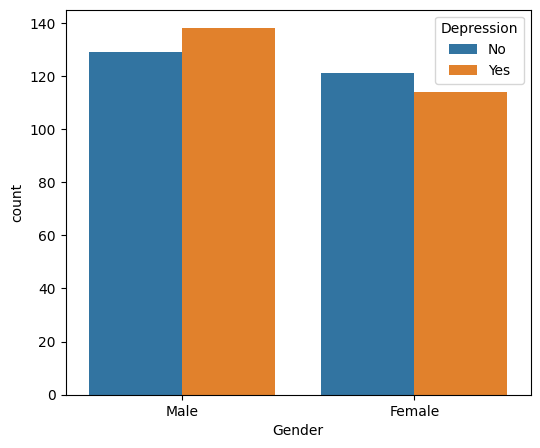

In [33]:
#Is depression equally distributed across males and females?

plt.figure(figsize=(6,5))
sns.countplot(data=hdu,
              x='Gender',
              hue='Depression')



plt.show()

**observation**

The distribution of depression is broadly similar between male and female students. Although there are slightly more males with depression than without, the difference is small, and the overall pattern suggests that gender alone is unlikely to be a strong predictor of depression in this dataset. Further statistical analysis will be performed to determine whether this apparent difference is statistically significant.

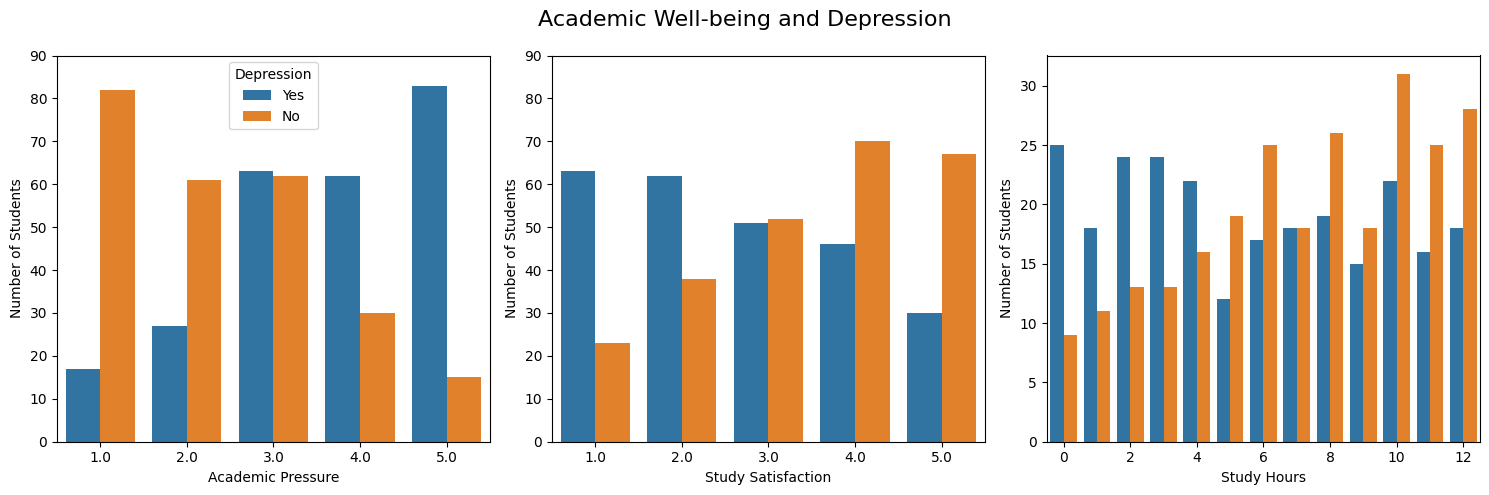

In [34]:
# Visualize the relationship between academic factors (academic pressure,
# study satisfaction, and study hours) and depression status.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Academic Pressure
sns.countplot(
    data=hdu,
    x='Academic Pressure',
    hue='Depression',
    ax=axes[0]
)

axes[0].set_xlabel('Academic Pressure')
axes[0].set_ylabel('Number of Students')

# Study Satisfaction
sns.countplot(
    data=hdu,
    x='Study Satisfaction',
    hue='Depression',
    ax=axes[1]
)

axes[1].set_xlabel('Study Satisfaction')
axes[1].set_ylabel('Number of Students')

# Sleep Duration
sns.countplot(
    data=hdu,
    x='Study Hours',
    hue='Depression',
    ax=axes[2]
)

axes[2].set_xticks(range(0, 13, 2))
axes[2].set_xlabel('Study Hours')
axes[2].set_ylabel('Number of Students')




# Keep only one legend
axes[1].legend_.remove()
axes[2].legend_.remove()
axes[0].set_ylim(0,90)
axes[1].set_ylim(0,90)

plt.suptitle("Academic Well-being and Depression",
             fontsize=16)

plt.tight_layout()
plt.show()

**observation**

A clear trend is observed between academic pressure and depression status (left panel). Students reporting lower levels of academic pressure (levels 1 and 2) are predominantly classified as not depressed, whereas those reporting higher levels of academic pressure (levels 4 and 5) are more likely to be classified as depressed. This suggests that academic pressure may be an important predictor of depression and a valuable feature for the subsequent machine learning models.

Conversely, study satisfaction exhibits the opposite pattern (middle panel). Students reporting higher levels of study satisfaction are more frequently classified as not depressed, whereas lower levels of study satisfaction are associated with a greater prevalence of depression.

The relationship between study hours and depression (right panel) suggests that students who study for longer durations tend to report depression more frequently than those studying fewer hours, although this trend is less pronounced than those observed for academic pressure and study satisfaction.

Overall, these findings indicate that academic-related factors are associated with depression status and may provide valuable predictive information for the machine learning models developed in this study.

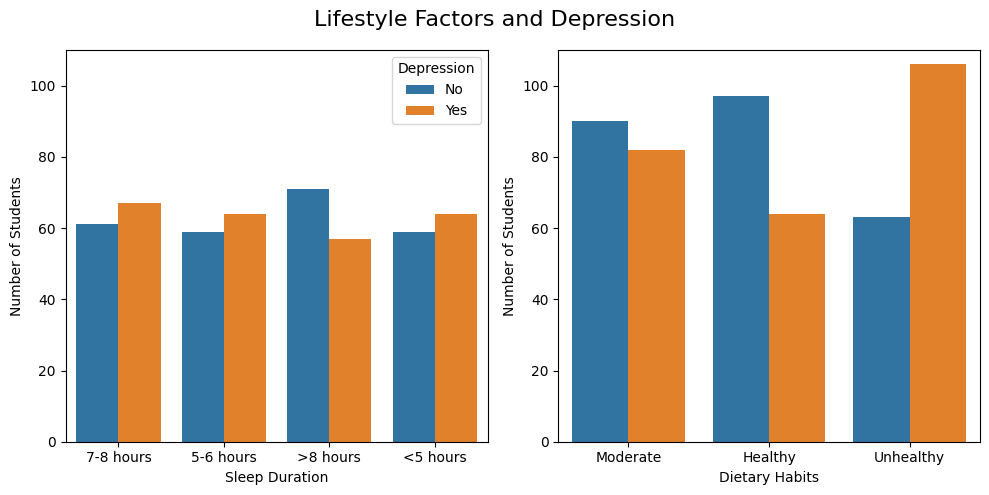

In [35]:
#does lifestyle play a role in depression?

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Academic Pressure
sns.countplot(
    data=hdu,
    x='Sleep Duration',
    hue='Depression',
    ax=axes[0]
)
#axes[0].set_title('Sleep Duration')
#axes[0].set_xlabel('Academic Pressure')
axes[0].set_ylabel('Number of Students')
#axes[0].tick_params(axis='x', labelrotation=45)

# Study Satisfaction
sns.countplot(
    data=hdu,
    x='Dietary Habits',
    hue='Depression',
    ax=axes[1]
)
#axes[1].set_title('Dietary Habits')
#axes[1].set_xlabel('Study Satisfaction')
axes[1].set_ylabel('Number of Students')



# Keep only one legend
axes[1].legend_.remove()
#set same limits
axes[0].set_ylim(0,110)
axes[1].set_ylim(0,110)

plt.suptitle("Lifestyle Factors and Depression",
             fontsize=16)

plt.tight_layout()
plt.show()

**observation**

This shows the relationship between lifestyle factors and depression. Sleep duration (left panel) exhibits a modest association with depression, with students reporting less than five hours of sleep appearing more likely to experience depression than those sleeping more than eight hours, who are predominantly classified as not depressed. However, the intermediate sleep categories show relatively balanced distributions, suggesting that the relationship between sleep duration and depression is less pronounced than that observed for academic-related factors.

Dietary habits (right panel) demonstrate a clearer pattern. Students reporting healthy dietary habits are more frequently classified as not depressed, whereas those reporting unhealthy dietary habits are substantially more likely to be classified as depressed. Students with moderate dietary habits exhibit a more balanced distribution between the two groups.

Overall, these findings suggest that healthy lifestyle behaviours, particularly dietary habits, are associated with lower levels of depression and may provide useful predictive information for the machine learning models.

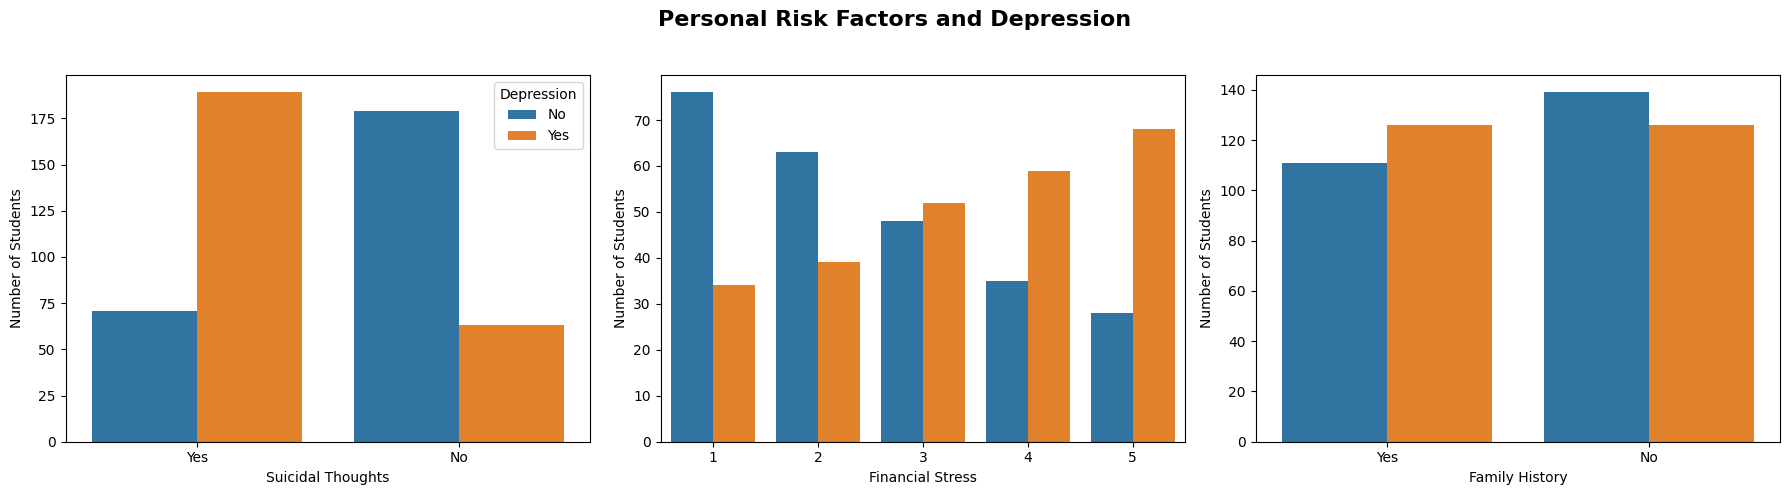

In [38]:
# Visualize the relationship between personal risk factors and depression status.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -----------------------------
# Suicidal Thoughts vs Depression
# -----------------------------
sns.countplot(
    data=hdu,
    x='Suicidal Thoughts',
    hue='Depression',
    ax=axes[0]
)


axes[0].set_xlabel("Suicidal Thoughts")
axes[0].set_ylabel("Number of Students")

# -----------------------------
# Financial Stress vs Depression
# -----------------------------
sns.countplot(
    data=hdu,
    x='Financial Stress',
    hue='Depression',
    ax=axes[1]
)


axes[1].set_xlabel("Financial Stress")
axes[1].set_ylabel("Number of Students")

# -----------------------------
# Family History vs Depression
# -----------------------------
sns.countplot(
    data=hdu,
    x='Family History',
    hue='Depression',
    ax=axes[2]
)


axes[2].set_xlabel("Family History")
axes[2].set_ylabel("Number of Students")

plt.suptitle(
    "Personal Risk Factors and Depression",
    fontsize=16,
    fontweight="bold"
)

# Keep only one legend
axes[1].legend_.remove()
axes[2].legend_.remove()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**observation**

Here the figure illustrates the relationship between personal, financial, and family factors and depression. Suicidal thoughts (left panel) exhibit the strongest association with depression, with the majority of students reporting suicidal thoughts being classified as depressed, whereas students reporting no suicidal thoughts are predominantly classified as not depressed.

Financial stress (middle panel) also demonstrates a clear positive relationship with depression. Students reporting lower levels of financial stress (levels 1–2) are more frequently classified as not depressed, while those reporting higher levels of financial stress (levels 4–5) are increasingly likely to be classified as depressed. This suggests that financial stress may be an important predictor of depression.

Family history of mental illness (right panel) shows a weaker association with depression. Students with a family history of mental illness exhibit a slightly higher prevalence of depression compared with those without such a history, although the difference is less pronounced than that observed for suicidal thoughts and financial stress.

Overall, these findings suggest that personal and financial factors, particularly suicidal thoughts and financial stress, are strongly associated with depression status and are likely to contribute substantially to the predictive performance of the machine learning models.

### Summary of EDA

The exploratory analysis indicates that academic pressure, study satisfaction, financial stress, suicidal thoughts, dietary habits, and study hours are the variables most strongly associated with depression in this dataset. These findings provide a strong basis for developing machine learning models to predict depression status.

## Machine Learning Models

The objective of this study was to predict whether a student is likely to experience depression using supervised machine learning. Before model training, categorical variables were encoded into numerical values, and the dataset was divided into training (80%) and testing (20%) subsets using stratified sampling to preserve the class distribution.

Three classification algorithms were evaluated:

- Logistic Regression
- Random Forest Classifier
- Decision Tree Classifier

Because Logistic Regression is sensitive to the scale of the input variables, the predictor variables were standardized using `StandardScaler`. Decision Tree and Random Forest do not require feature scaling.

In [39]:
#Feature Engineering and Data Preparation

# Separate predictor variables and target variable
X = hdu.drop(columns="Depression")
y = hdu["Depression"]

# Encode categorical predictor variables
categorical_columns = [
    "Gender",
    "Sleep Duration",
    "Dietary Habits",
    "Suicidal Thoughts",
    "Family History"
]

encoder = LabelEncoder()

for column in categorical_columns:
    X[column] = encoder.fit_transform(X[column])

# Encode target variable
y = encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=230,
    stratify=y
)

# Standardize features for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression and evaluation
Accuracy: 0.941

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.90      0.94        50
           1       0.91      0.98      0.94        51

    accuracy                           0.94       101
   macro avg       0.94      0.94      0.94       101
weighted avg       0.94      0.94      0.94       101

Confusion Matrix


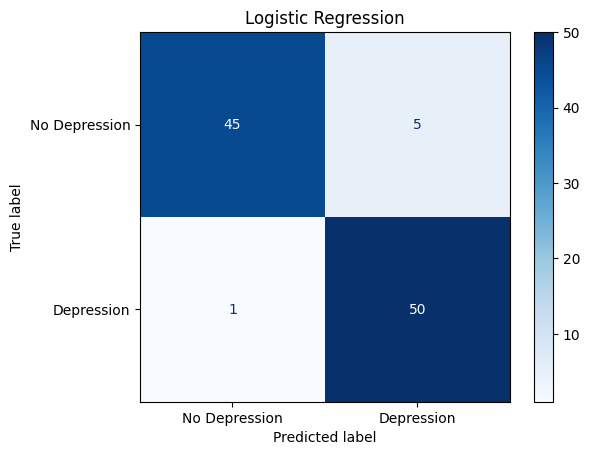

In [40]:
print("="*50)
print("Logistic Regression and evaluation")
print("="*50)


LR_model = LogisticRegression(max_iter=1000)

LR_model.fit(X_train_scaled, y_train)

LR_predictions = LR_model.predict(X_test_scaled)



print(f"Accuracy: {accuracy_score(y_test, LR_predictions):.3f}\n")

print("Classification Report")
print(classification_report(y_test, LR_predictions))

print("Confusion Matrix")

cm = confusion_matrix(y_test, LR_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression")
plt.show()


***Random Forest and  DecisionTree Classifier and evaluation***
Random Forest
Accuracy: 0.941

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        50
           1       0.94      0.94      0.94        51

    accuracy                           0.94       101
   macro avg       0.94      0.94      0.94       101
weighted avg       0.94      0.94      0.94       101

Confusion Matrix


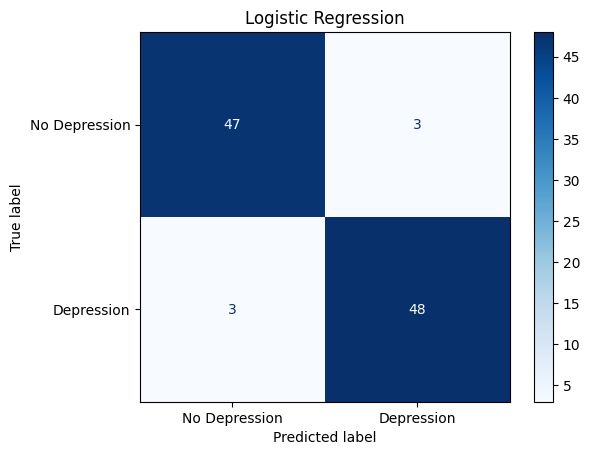


Decision Tree
Accuracy: 0.891

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        50
           1       0.88      0.90      0.89        51

    accuracy                           0.89       101
   macro avg       0.89      0.89      0.89       101
weighted avg       0.89      0.89      0.89       101

Confusion Matrix


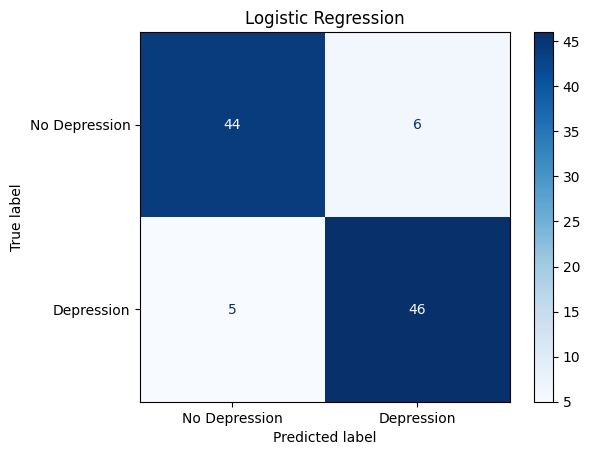

In [41]:
#print("="*50)
print("***Random Forest and  DecisionTree Classifier and evaluation***")
#print("*"*50)




# Dictionary of tree-based models
models = {
    "Random Forest": RandomForestClassifier(random_state=230),
    "Decision Tree": DecisionTreeClassifier(random_state=230)
}

RF_predictions = None
DT_predictions = None

for model_name, model in models.items():

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    if model_name == "Random Forest":
        RF_predictions = predictions

    elif model_name == "Decision Tree":
        DT_predictions = predictions

    # Evaluate
    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy: {accuracy_score(y_test, predictions):.3f}\n")

    print("Classification Report")
    print(classification_report(y_test, predictions))

    print("Confusion Matrix")
    #print(confusion_matrix(y_test, predictions))
    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Depression", "Depression"]
    )

    disp.plot(cmap="Blues")

    plt.title("Logistic Regression")
    plt.show()
    print()

## Discussion

**Logistic Regression**

Logistic Regression achieved an accuracy of 94.1%. The model achieved performance high precision, recall, and F1-scores for both classes. It showed a slight tendency to produce more false positives (5) than false negatives (1). This indicates that the model was more likely to incorrectly identify a non-depressed student as depressed than to miss a student with depression.

**Random Forest**

Random Forest also achieved an accuracy of 94.1%, matching Logistic Regression. The model produced balanced precision, recall, and F1-scores (0.94) for both classes. The confusion matrix showed three false positives and three false negatives, indicating balanced performance across both classes.

**Decision Tree**

Decision Tree achieved an accuracy of 89.1%, making 11 misclassifications. Although it performed reasonably well, its accuracy and classification metrics were lower than those of Logistic Regression and Random Forest.


Although Logistic Regression and Random Forest achieved the same overall accuracy (94.1%), Logistic Regression produced only one false negative, compared with three for Random Forest. In the context of depression prediction, minimizing false negatives is particularly important because it reduces the number of students with depression who are incorrectly classified as not depressed. Furthermore, Logistic Regression is simpler and more interpretable than Random Forest, making it easier to understand how each predictor contributes to the classification. For these reasons, Logistic Regression was selected as the preferred model.

## Conclusion

The exploratory data analysis revealed that several factors were associated with depression among students. Higher academic pressure, greater financial stress, and suicidal thoughts were associated with a higher prevalence of depression, whereas greater study satisfaction, adequate sleep, and healthier dietary habits were associated with a lower prevalence of depression. Family history also showed an association with depression.

The machine learning models showed that the relationships identified during the exploratory analysis could be used to accurately predict depression status. Logistic Regression and Random Forest both achieved an accuracy of 94.1%, indicating that the patterns identified during the exploratory analysis provide strong predictive information. Although both models performed equally well in terms of accuracy, Logistic Regression produced fewer false negatives, making it the preferred model for identifying students with depression. The Decision Tree classifier achieved a lower accuracy (89.1%), indicating weaker predictive performance than the other two models.

Overall, the exploratory data analysis identified the factors associated with depression, while the machine learning models confirmed that these factors collectively have strong predictive value. This study demonstrates how combining exploratory data analysis with supervised machine learning can provide meaningful insights into student mental health. Such predictive models could support the early identification of students who may be at risk of depression, enabling institutions to consider timely interventions and appropriate mental health support.

## References for libraries used


1. Pedregosa, Fabian, et al. "Scikit-learn: Machine learning in Python." the Journal of machine Learning research 12 (2011): 2825-2830.
2. McKinney, Wes. "pandas: a foundational Python library for data analysis and statistics." Python for high performance and scientific computing 14.9 (2011): 1-9.
3. Hunter, John D. "Matplotlib: A 2D graphics environment." Computing in science & engineering 9.3 (2007): 90-95.
4. Waskom, Michael L. "Seaborn: statistical data visualization." Journal of open source software 6.60 (2021): 3021.